# 1. Sea $(X_1, X_2)$ un vector aleatorio con densidad conjunta
# $$f(x_1, x_2) =\frac{1}{2πσ}exp(-\frac{x^2_1}{2}-\frac{(x_2-x_1)^2}{2σ^2}).$$

## (a) Obtén la distribución de $X_1$ y la distribución de $X_2 | X_1$.


$$f_{X_1} = \int_{-\infty}^{\infty} f_{X_1,X_2}(x_1, x_2) \, dx_2 = \int_{-\infty}^{\infty} \frac{1}{2\pi \sigma} \exp\left\{ -\frac{x_1^2}{2} - \frac{(x_2 - x_1)^2}{2\sigma^2} \right\} \, dx_2$$

$$= \frac{\exp\left\{ -\frac{x_1^2}{2} \right\}}{\sqrt{2\pi}} \int_{-\infty}^{\infty} \frac{1}{\sigma \sqrt{2\pi}} \exp\left\{ -\frac{(x_2 - x_1)^2}{2\sigma^2} \right\} \, dx_2 = \frac{\exp\left\{ -\frac{x_1^2}{2} \right\}}{\sqrt{2\pi}} \sim N(0, 1)$$



Y

$$f_{X_2 | X_1}(x_2 | x_1) = \frac{f_{X_1, X_2}(x_1, x_2)}{f_{X_1}(x_1)} = \frac{\frac{1}{2\pi \sigma} {\exp\left\{ -\frac{x_1^2}{2} \right\}} \exp\left\{ -\frac{(x_2 - x_1)^2}{2\sigma^2} \right\}}{\frac{1}{\sqrt{2\pi}} {\exp\left\{ -\frac{x_1^2}{2} \right\}}}$$

$$= \frac{1}{\sigma \sqrt{2\pi}} \exp\left\{ -\frac{(x_2 - x_1)^2}{2\sigma^2} \right\} \sim N(x_1, \sigma^2)$$

## (b) Implementa un algoritmo para generar $N$ realizaciones del vector $(X_1, X_2)$ utilizando muestreo condicional.

In [ ]:
import numpy as np

def norm_biv(N, simga2 = 1, seed = 29):
  np.random.seed(seed)
  X1 = np.random.normal(size = N)
  X2 = np.random.normal(loc = X1, scale = np.sqrt(simga2))
  return np.array([X1, X2]).T

In [ ]:
N = 10

norm_biv(N, 10)

array([[-0.41748213, -0.82553748],
       [ 0.7060321 , -1.28892378],
       [ 1.9159847 , -2.6327077 ],
       [-2.1417555 , -0.07930237],
       [ 0.71905689,  3.83372837],
       [ 0.46707262, -3.15185819],
       [ 0.76672253,  1.99000679],
       [ 0.88200945,  2.23098933],
       [ 0.80875066,  7.4699661 ],
       [-0.94716485, -1.57287059]])

## (c) Grafica las curvas de nivel de la densidad conjunta y superpón una muestra simulada.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_norm_biv(N, sigma2 = 1, seed = 29):
    sigma = np.sqrt(sigma2)
    X = norm_biv(N, sigma2, seed)
    X1, X2 = X[:, 0], X[:, 1]
    X1_dom = np.linspace(-4, 4, 100)
    X2_dom = np.linspace(-4*sigma, 4* sigma, 100)
    X1_grid, X2_grid = np.meshgrid(X1_dom, X2_dom)
    Z = (1 / (2 * np.pi * sigma)) * np.exp(- (X1_grid**2) / 2 - ((X2_grid - X1_grid)**2) / (2 * sigma2))

    sns.set_theme(style="whitegrid")
    sns.scatterplot(x=X1, y=X2, alpha=0.5, label=r"$(X_1, X_2)$")
    contours = plt.contour(X1_grid, X2_grid, Z, levels=5, cmap='plasma', linewidths=1)
    plt.clabel(contours, inline=True, fontsize=10, fmt='%.3f')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend(loc='upper left')
    plt.show()

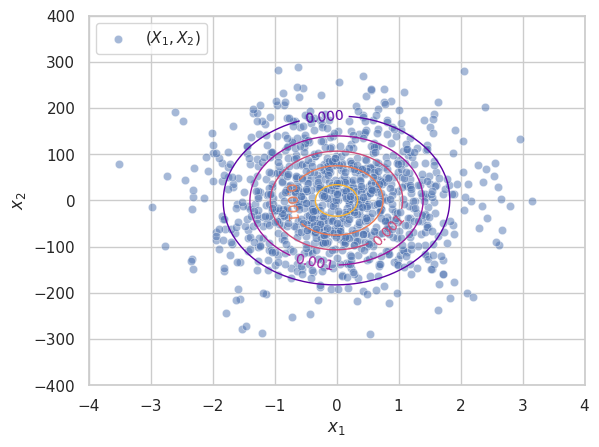

In [ ]:
plot_norm_biv(1000, 10000)

## (d) Encuentra $\mathbb{E}(X_2)$, $\mathbb{Var}(X_2)$ y $\mathbb{Cov}(X_1, X_2)$ y compara estos valores con la esperanza, varianza y covarianza muestral. Comenta en los resultados obtenidos poniendo especial atención en la covarianza.

Dado que $X_2 \sim N(X_1, \sigma^2)$, entonces

$$\mathbb{E}(X_2) = \mathbb{E}[\mathbb{E}[X_2|X_1]] = \mathbb{E}(X_1) = 0$$

y

$$\mathbb{Var}(X_2) = \mathbb{Var}(\mathbb{E}[X_2|X_1]) + \mathbb{E}(\mathbb{Var}[X_2|X_1]) = \mathbb{Var}(X1) + \mathbb{E}[\sigma^2] = 1 + \sigma^2$$

ahora

$$\mathbb{Cov}(X_1, X_2) = \mathbb{E}(X_1X_2) =  \mathbb{E}[X_1\cdot\mathbb{E}(X_2| X_1)] = \mathbb{E}[X_1^2] = \mathbb{Var}(X_1) + \mathbb{E}[X_1]^2 = 1.$$

In [ ]:
X = norm_biv(10000, 100000)
X1, X2 = X[:, 0], X[:, 1]

media_m = np.mean(X2)
var_m = np.var(X2)
cov_m = np.cov(X1, X2)[0, 1]
print(f"Media muestral = {media_m}")
print(f"Varianza muestral = {var_m}")
print(f"Covarianza muestral = {cov_m}")

Media muestral = 1.2996214425335222
Varianza muestral = 100432.61326251244
Covarianza muestral = -0.9558391354562502


Al aumentar el valor de $\sigma^2 > N$, empezan a ocurrir problemas y los valores muestrales comienzan a alejarse de de los teóricos, particularmente el valor de la covarianza muestral. Esto es de esperarse pues los valores de $N$ no son lo suficientemente grandes.

# 2. Sea $X$ un vector aleatorio con distribución normal bivariada centrada en el origen y con matriz de varianza y covarianza $Σ$ dada por

# $$Σ = \begin{pmatrix} 1 & 0.7 \\ 0.7 & 1 \end{pmatrix},$$

# y sea $V ∼ \chi^2_ν$ independiente de X. Considera la transformación

# $$Y = \sqrt{\frac{ν}{V}}X.$$

# Realiza lo siguiente:

## (a) Muestra que la distribución condicional de $Y$ dado $V = v$ es

## $$Y | V = v ∼ N_2(0,\frac{ν}{v}Σ).$$

## La distribución marginal resultante de $Y$ es la distribución $t$ bivariada con $ν$ grados de libertad, vector de localización $0$ y matriz de escala $Σ$.

Si tenemos $Y|V = v$, entonces tendremos $\sqrt{\frac{\nu}{v}}X$, por lo cual $Y|V = v$ será una normal bivariada. En el caso unidimensional tenemos que el multiplicar por un escalar $c$ a una normal centrada en el 0 genera una normal de parametros $(0, c^2 \sigma^2)$, veamos si pasa lo mismo.

$$\mathbb{E}[Y|V=v] = \mathbb{E}[\sqrt{\frac{\nu}{v}}X] = \sqrt{\frac{\nu}{v}}\mathbb{E}[X] = 0$$

y

$$\mathbb{Var}(Y|V=v) = \mathbb{Var}(\sqrt{\frac{\nu}{v}}X) = \frac{\nu}{v}\mathbb{Var}(X) = \frac{\nu}{v}\Sigma$$

Por lo tanto, $Y|V=v \sim N(0,\frac{\nu}{v}Sigma)$

## (b) Utilizando la representación anterior, implementa un algoritmo para generar una muestra de tamaño $N$ de la distribución $t$ bivariada.

In [34]:
def dist_t(N, nu = 1, seed = 29):
  np.random.seed(seed)
  Sigma = np.array([[1, 0.7], [0.7, 1]])
  V = np.sum(np.square(np.random.normal(size = (N, nu))), axis = 1)
  X = np.random.normal(size = (N, 2))
  A = np.linalg.cholesky(Sigma)
  Y = np.sqrt(nu/V).reshape(-1, 1) * X @ A
  return Y

In [35]:
dist_t(10000)

array([[-1.55477611,  0.59824742],
       [ 0.63199327,  0.48545457],
       [-1.81388249, -0.59574654],
       ...,
       [ 1.83535186,  1.8828092 ],
       [-1.86347974, -0.91301347],
       [-2.80606839, -0.78129213]])

## (c) Utiliza tu algoritmo para generar muestras de la distribución $t$ bivariada para $ν = 2, 5, 10, 30$. Para cada valor de $ν$, realiza una gráfica de dispersión de la muestra y compárala con una muestra de una distribución $N_2(0, Σ)$. Describe el efecto que tienen los grados de libertad sobre el comportamiento de la distribución.

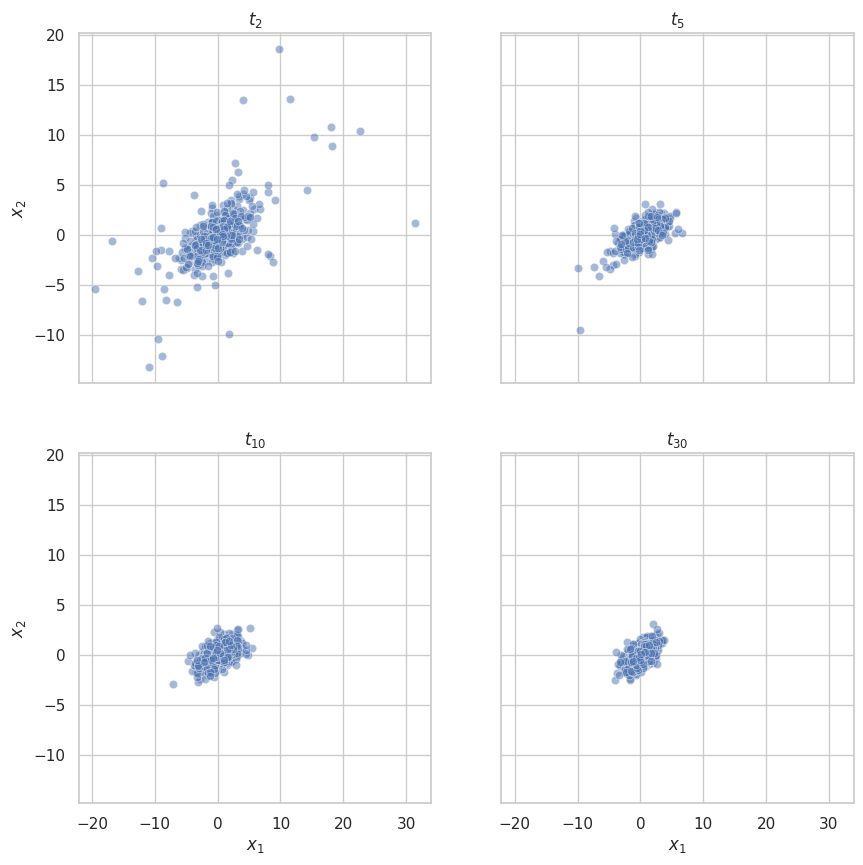

In [36]:
nu = [2, 5, 10, 30]
N = 1000
Y = []

for i in nu:
  Y.append(dist_t(N, i))

fig, ax = plt.subplots(2, 2, figsize = (10, 10), sharex = True, sharey = True)
sns.scatterplot(x = Y[0][:, 0], y = Y[0][:, 1], alpha = 0.5, ax = ax[0, 0])
ax[0, 0].set_xlabel('$x_1$')
ax[0, 0].set_ylabel('$x_2$')
ax[0, 0].set_title(f"$t_{nu[0]}$")
sns.scatterplot(x = Y[1][:, 0], y = Y[1][:, 1], alpha = 0.5, ax = ax[0, 1])
ax[0, 1].set_xlabel('$x_1$')
ax[0, 1].set_ylabel('$x_2$')
ax[0, 1].set_title(f"$t_{nu[1]}$")
sns.scatterplot(x = Y[2][:, 0], y = Y[2][:, 1], alpha = 0.5, ax = ax[1, 0])
ax[1, 0].set_xlabel('$x_1$')
ax[1, 0].set_ylabel('$x_2$')
ax[1, 0].set_title(f"$t_{{{nu[2]}}}$")
sns.scatterplot(x = Y[3][:, 0], y = Y[3][:, 1], alpha = 0.5, ax = ax[1, 1])
ax[1, 1].set_xlabel('$x_1$')
ax[1, 1].set_ylabel('$x_2$')
ax[1, 1].set_title(f"$t_{{{nu[3]}}}$")
plt.show()

## (d) Para cada observación simulada $\mathbf{y}_i$, calcula la distancia de Mahalanobis al cuadrado

## $$d_i^2 = \mathbf{y}_i^\top \Sigma^{-1} \mathbf{y}_i.$$

## Para cada valor de $\nu$, calcula la proporción de observaciones de la distribución $t$ que se encuentran fuera de la región

## $$\mathbf{y}^\top \Sigma^{-1} \mathbf{y} \leq \chi^2_{2, 0.95}.$$

## ¿Cómo se comparan estas proporciones con las de la distribución normal? Recuerda que, para un vector normal, la región

## $$\mathbf{x}^\top \Sigma^{-1} \mathbf{x} \leq \chi^2_{2, 0.95}$$

## contiene el 95% de la probabilidad de la distribución normal bivariada. Interpreta tus resultados en términos del comportamiento de las colas.

Distancia de Mahalanobis

In [37]:
def dist_mahalanobis(Y):
  Sigma_inv = np.linalg.inv(np.array([[1, 0.7], [0.7, 1]]))
  dist = np.zeros(Y.shape[0])
  for i in range(Y.shape[0]):
    dist[i] = Y[i, :].T @ Sigma_inv @ Y[i, :]
  return dist

dist_mahalanobis(Y[0])[:10]

array([1.96872866, 0.03395075, 3.55604985, 0.52190967, 4.01315993,
       9.55724158, 2.75749166, 1.06611193, 0.12946872, 1.44425606])

Comparacion con la región

In [38]:
from scipy.stats import chi2

def region(Y):
  q = chi2.ppf(0.95, df = 2)
  porc_dentro = []
  for i in range(len(Y)):
    dist = dist_mahalanobis(Y[i])
    porc_dentro.append(np.mean(dist <= q))
  return np.array(porc_dentro)

region(Y)

array([0.692, 0.813, 0.841, 0.89 ])

Estos resultados tienen sentido considerando que la dist t de student tiene colas mas pesadas que una normal. Además mientras menor sea los grados de libertad, mas pesadas serán las colas. Y cuando el numero de grados de libertad tiende a infinito, esta distribucion converge a una normal, por lo cual debería ocurir que los valores que estan dentro de la región deberían tambien converger a 0.95.

## (e) Recuerda que si $V \sim \chi^2_\nu$, entonces $\mathbb{E}(V) = \nu$ y $\mathrm{Var}(V) = 2\nu$. Estudia la media y la varianza de $V/\nu$ cuando $\nu \to \infty$ y utiliza la desigualdad de Chebyshev para mostrar que $V/\nu$ converge en probabilidad a 1. A partir de la representación

## $$\mathbf{Y} = \frac{\mathbf{X}}{\sqrt{V/\nu}},$$

## explica qué sucede con la distribución de $\mathbf{Y}$ cuando $\nu \to \infty$.

Veamos el limite  de la esperanza primero

$$\lim\limits_{\nu \to \infty} \mathbb{E}[\frac{V}{\nu}] =  \lim\limits_{\nu \to \infty} \frac{\mathbb{E}[V]}{\nu} = \lim\limits_{\nu \to \infty} \frac{\nu}{\nu} = 1$$

y la varianza

$$\lim\limits_{\nu \to \infty} \mathbb{Var}(\frac{V}{\nu}) = \lim\limits_{\nu \to \infty} \frac{\mathbb{Var}(V)}{\nu^2} = \lim\limits_{\nu \to \infty} \frac{2\nu}{\nu^2} = \lim\limits_{\nu \to \infty} \frac{2}{\nu} = 0.$$

Ahora con la desigualdad de Chebyshev tenemos

$$\lim\limits_{\nu \to \infty} \mathbb{P}(|\frac{V}{\nu} - 1| \ge \epsilon) \le \frac{2}{\nu \epsilon^2} = 0$$

así que $\frac{V}{\nu}$ converge a 1 en probabilidad.

Así ocurre que $\sqrt{\frac{V}{\nu}}$ tambien converge en proba a 1, ya que su esperanza y varianza es la misma. Con lo cual cuando $\nu \to \infty$, $Y$ converge a $X$.